In [11]:
from PIL import Image
import cv2
import numpy as np
import glob
import os
from pathlib import Path
from collections import Counter
import random
import matplotlib.pyplot as plt


In [12]:
def find_project_root():
    current_path = Path.cwd().resolve()
    possible_paths = [current_path] + list(current_path.parents)

    for path in possible_paths:
        notebook_file = path / "notebook" / "preprocessing.ipynb"
        if notebook_file.exists():
            return path

    if current_path.name.lower() == "notebook":
        return current_path.parent

    return current_path


def count_tiff_files(folder):
    if not folder.exists():
        return 0

    return len(list(folder.glob("*.tiff"))) + len(list(folder.glob("*.tif")))


def find_data_folder(project_root):
    candidates = [project_root / "Data", project_root / "data"]

    for candidate in candidates:
        if candidate.exists() and count_tiff_files(candidate) > 0:
            return candidate

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return project_root / "Data"


PROJECT_ROOT = find_project_root()
DATA_DIR = find_data_folder(PROJECT_ROOT)
JPG_DIR = PROJECT_ROOT / "Data_jpg"
DENOISED_DIR = PROJECT_ROOT / "Data_denoised"

JPG_DIR.mkdir(exist_ok=True)
DENOISED_DIR.mkdir(exist_ok=True)

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Data folder used:", DATA_DIR)
print("JPG output folder:", JPG_DIR)
print("Denoised output folder:", DENOISED_DIR)

if DATA_DIR.exists():
    print("Data folder exists.")
else:
    print("Data folder does not exist yet. Create a folder named Data or data and put TIFF images inside it.")


Current working directory: /Users/khalidatef/Documents/image-processing-project/notebook
Project root: /Users/khalidatef/Documents/image-processing-project
Data folder used: /Users/khalidatef/Documents/image-processing-project/Data
JPG output folder: /Users/khalidatef/Documents/image-processing-project/Data_jpg
Denoised output folder: /Users/khalidatef/Documents/image-processing-project/Data_denoised
Data folder exists.


In [13]:
def list_images(folder, extensions):
    if not folder.exists():
        return []

    files = []
    for extension in extensions:
        files.extend(glob.glob(str(folder / extension)))

    return sorted(set(files))


def refresh_file_lists():
    tiff_files = list_images(DATA_DIR, ["*.tiff", "*.tif"])
    jpg_files = list_images(JPG_DIR, ["*.jpg", "*.jpeg"])
    denoised_files = list_images(DENOISED_DIR, ["*.jpg", "*.jpeg"])
    return tiff_files, jpg_files, denoised_files


def choose_sample_image():
    tiff_files, jpg_files, denoised_files = refresh_file_lists()

    if jpg_files:
        return Path(jpg_files[0])
    if tiff_files:
        return Path(tiff_files[0])
    if denoised_files:
        return Path(denoised_files[0])

    return None


def show_gray_image(image, title):
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")


In [14]:
tiff_files, jpg_files, denoised_files = refresh_file_lists()

print("Data folder exists:", DATA_DIR.exists())
print("Number of TIFF images:", len(tiff_files))
print("Number of JPG images:", len(jpg_files))
print("Number of denoised images:", len(denoised_files))

if len(tiff_files) == 0:
    print("No TIFF images found yet. Put your .tiff or .tif files inside the Data/data folder, then run the notebook again.")
else:
    print("TIFF images are ready for processing.")


Data folder exists: True
Number of TIFF images: 18038
Number of JPG images: 18038
Number of denoised images: 18038
TIFF images are ready for processing.


In [15]:
tiff_files, jpg_files, denoised_files = refresh_file_lists()
converted_count = 0
skipped_count = 0

if len(tiff_files) == 0:
    print("Conversion skipped because no TIFF images were found.")
else:
    for file in tiff_files:
        image = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print("Skipped unreadable image:", Path(file).name)
            skipped_count += 1
            continue

        output_name = Path(file).stem + ".jpg"
        save_path = JPG_DIR / output_name
        cv2.imwrite(str(save_path), image)
        converted_count += 1

    print(f"Converted {converted_count} TIFF images to grayscale JPG.")
    print(f"Skipped {skipped_count} unreadable images.")

_, jpg_files, _ = refresh_file_lists()
print("Number of JPG images after conversion:", len(jpg_files))


Converted 18038 TIFF images to grayscale JPG.
Skipped 0 unreadable images.
Number of JPG images after conversion: 18038


In [16]:
tiff_files, jpg_files, denoised_files = refresh_file_lists()

print("Number of TIFF images:", len(tiff_files))
print("Number of JPG images:", len(jpg_files))

if len(jpg_files) == 0:
    print("No JPG images found. Run the conversion section after adding TIFF images.")
else:
    sample = cv2.imread(jpg_files[0], cv2.IMREAD_GRAYSCALE)

    if sample is None:
        print("The sample JPG image could not be read.")
    else:
        print("Sample image:", Path(jpg_files[0]).name)
        print("Sample image shape:", sample.shape)
        print("Sample image dtype:", sample.dtype)
        print("Minimum pixel value:", sample.min())
        print("Maximum pixel value:", sample.max())


Number of TIFF images: 18038
Number of JPG images: 18038
Sample image: RawDataQA-1-1 (1).jpg
Sample image shape: (300, 300)
Sample image dtype: uint8
Minimum pixel value: 1
Maximum pixel value: 253


In [17]:
tiff_files, jpg_files, denoised_files = refresh_file_lists()
sizes = []

if len(tiff_files) == 0:
    print("Size check skipped because no TIFF images were found.")
else:
    for file in tiff_files:
        image = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print("Skipped unreadable image:", Path(file).name)
            continue

        sizes.append(image.shape)

    size_counts = Counter(sizes)
    print("Number of different image sizes:", len(size_counts))

    for size, count in size_counts.items():
        print(f"Size {size}: {count} images")

    if len(size_counts) == 1:
        print("All readable images have the same size.")
    elif len(size_counts) > 1:
        print("The dataset contains images with different sizes.")


Number of different image sizes: 1
Size (300, 300): 18038 images
All readable images have the same size.


In [18]:
tiff_files, jpg_files, denoised_files = refresh_file_lists()
denoised_count = 0
skipped_count = 0

if len(tiff_files) == 0:
    print("Denoising skipped because no TIFF images were found.")
else:
    for file in tiff_files:
        image = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print("Skipped unreadable image:", Path(file).name)
            skipped_count += 1
            continue

        denoised = cv2.medianBlur(image, 5)
        output_name = Path(file).stem + ".jpg"
        save_path = DENOISED_DIR / output_name
        cv2.imwrite(str(save_path), denoised)
        denoised_count += 1

    print(f"Denoised {denoised_count} images.")
    print(f"Skipped {skipped_count} unreadable images.")

_, jpg_files, denoised_files = refresh_file_lists()
print("Number of JPG images:", len(jpg_files))
print("Number of denoised images:", len(denoised_files))

if len(tiff_files) == 0:
    print("No success message is shown because there are no original TIFF images yet.")
else:
    if denoised_count > 0 and len(denoised_files) >= denoised_count:
        print("Denoising finished for the readable images.")
    else:
        print("Denoising is incomplete. Check unreadable files or output folder contents.")


Denoised 18038 images.
Skipped 0 unreadable images.
Number of JPG images: 18038
Number of denoised images: 18038
Denoising finished for the readable images.


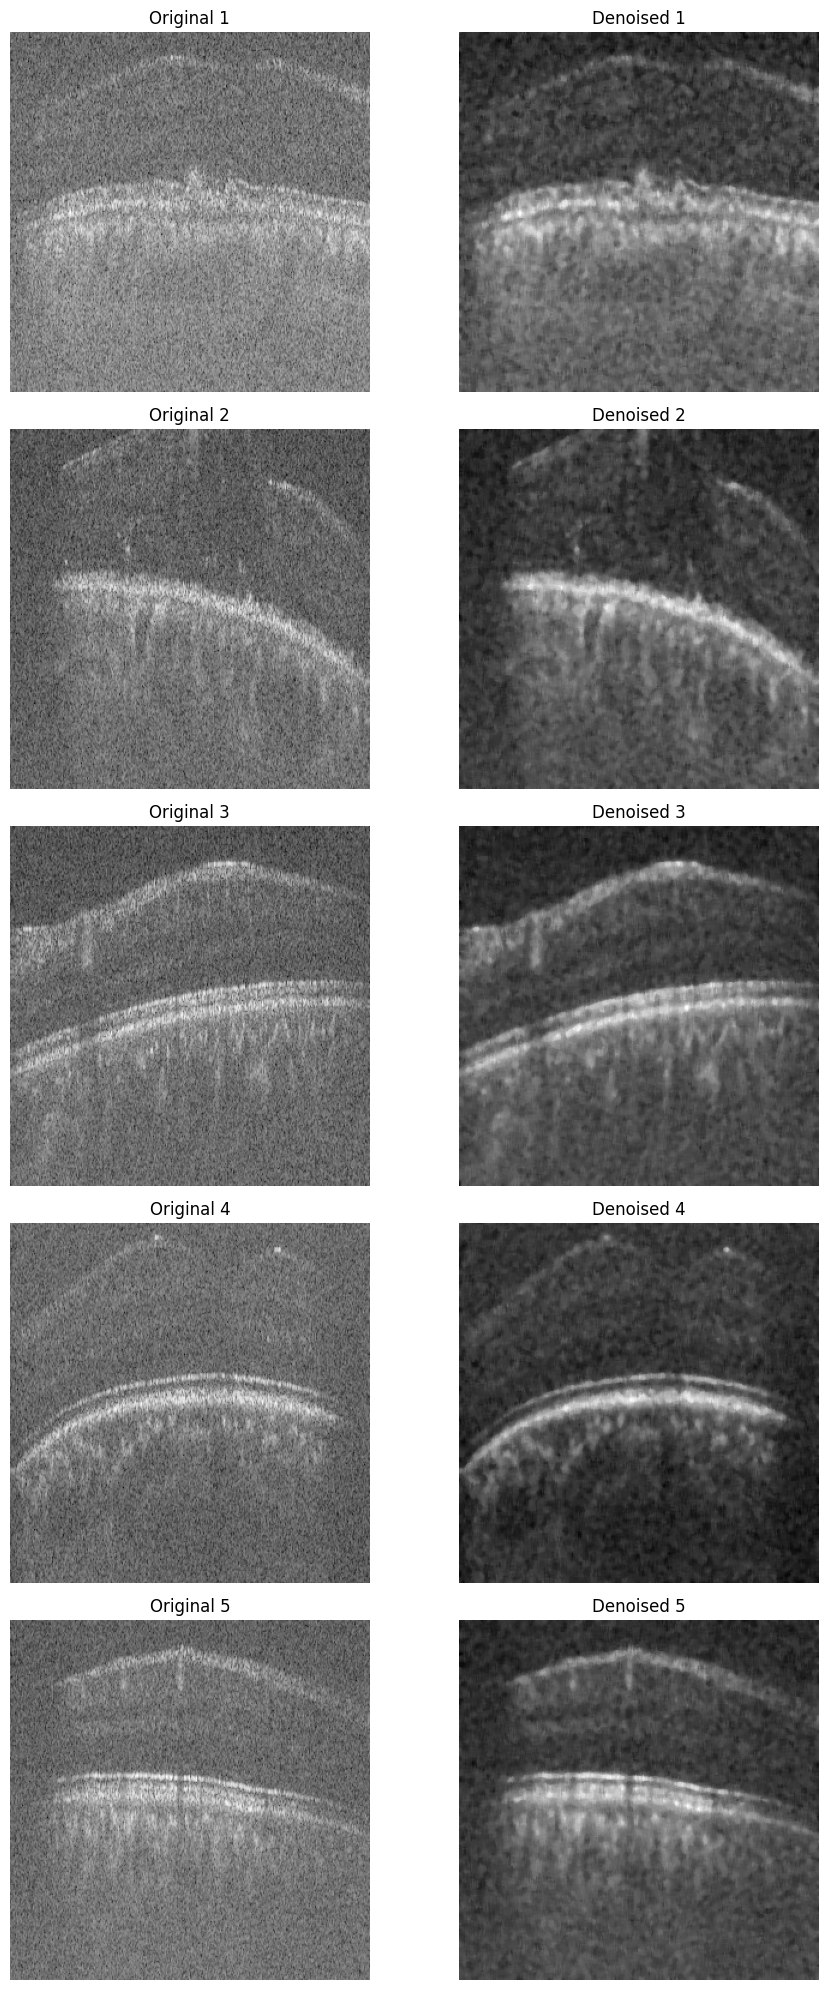

In [19]:
tiff_files, jpg_files, denoised_files = refresh_file_lists()

denoised_by_name = {Path(file).name: file for file in denoised_files}
matched_pairs = []

for original_file in jpg_files:
    file_name = Path(original_file).name
    if file_name in denoised_by_name:
        matched_pairs.append((original_file, denoised_by_name[file_name]))

if len(matched_pairs) == 0:
    print("No matching original and denoised JPG images found yet.")
else:
    sample_count = min(5, len(matched_pairs))
    selected_pairs = random.sample(matched_pairs, sample_count)

    fig, axes = plt.subplots(sample_count, 2, figsize=(10, 4 * sample_count))

    if sample_count == 1:
        axes = np.array([axes])

    for index, (original_file, denoised_file) in enumerate(selected_pairs):
        original = cv2.imread(original_file, cv2.IMREAD_GRAYSCALE)
        denoised = cv2.imread(denoised_file, cv2.IMREAD_GRAYSCALE)

        axes[index, 0].imshow(original, cmap="gray")
        axes[index, 0].set_title(f"Original {index + 1}")
        axes[index, 0].axis("off")

        axes[index, 1].imshow(denoised, cmap="gray")
        axes[index, 1].set_title(f"Denoised {index + 1}")
        axes[index, 1].axis("off")

    plt.tight_layout()
    plt.show()


In [20]:
sample_path = choose_sample_image()

if sample_path is None:
    print("No sample image available yet. Add TIFF images and run the conversion section first.")
else:
    print("Sample image used:", sample_path.name)

    pil_image = Image.open(sample_path)
    print("\nPIL")
    print("Type:", type(pil_image))
    print("Format:", pil_image.format)
    print("Mode:", pil_image.mode)
    print("Size:", pil_image.size)
    pil_image.close()

    matplotlib_image = plt.imread(str(sample_path))
    print("\nMatplotlib")
    print("Type:", type(matplotlib_image))
    print("Shape:", matplotlib_image.shape)
    print("Dtype:", matplotlib_image.dtype)

    opencv_image = cv2.imread(str(sample_path), cv2.IMREAD_UNCHANGED)
    print("\nOpenCV")
    print("Type:", type(opencv_image))

    if opencv_image is None:
        print("OpenCV could not read the image.")
    else:
        print("Shape:", opencv_image.shape)
        print("Dtype:", opencv_image.dtype)


Sample image used: RawDataQA-1-1 (1).jpg

PIL
Type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Format: JPEG
Mode: L
Size: (300, 300)

Matplotlib
Type: <class 'numpy.ndarray'>
Shape: (300, 300)
Dtype: uint8

OpenCV
Type: <class 'numpy.ndarray'>
Shape: (300, 300)
Dtype: uint8


The sample image is grayscale. It has one channel, so it does not have separate RGB channels.


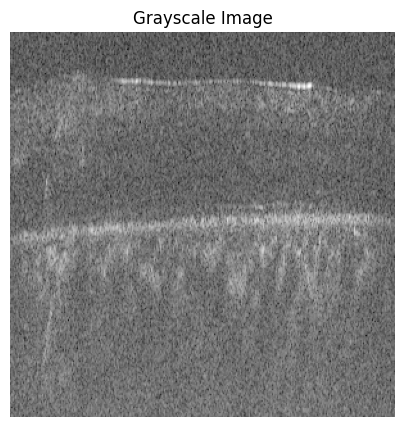

In [21]:
sample_path = choose_sample_image()

if sample_path is None:
    print("No sample image available yet.")
else:
    image = cv2.imread(str(sample_path), cv2.IMREAD_UNCHANGED)

    if image is None:
        print("OpenCV could not read the sample image.")
    elif len(image.shape) == 2:
        print("The sample image is grayscale. It has one channel, so it does not have separate RGB channels.")
        plt.figure(figsize=(5, 5))
        show_gray_image(image, "Grayscale Image")
        plt.show()
    elif len(image.shape) == 3 and image.shape[2] >= 3:
        if image.shape[2] == 4:
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGB)
        else:
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        red_channel = rgb_image[:, :, 0]
        green_channel = rgb_image[:, :, 1]
        blue_channel = rgb_image[:, :, 2]

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].imshow(rgb_image)
        axes[0].set_title("RGB Image")
        axes[0].axis("off")

        axes[1].imshow(red_channel, cmap="Reds")
        axes[1].set_title("Red Channel")
        axes[1].axis("off")

        axes[2].imshow(green_channel, cmap="Greens")
        axes[2].set_title("Green Channel")
        axes[2].axis("off")

        axes[3].imshow(blue_channel, cmap="Blues")
        axes[3].set_title("Blue Channel")
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("Unsupported image shape:", image.shape)


In [22]:
sample_path = choose_sample_image()

if sample_path is None:
    print("No sample image available yet.")
else:
    unchanged_image = cv2.imread(str(sample_path), cv2.IMREAD_UNCHANGED)

    if unchanged_image is None:
        print("OpenCV could not read the sample image.")
    elif len(unchanged_image.shape) == 2:
        print("The sample image is grayscale. BGR, RGB, and HSV color-space examples need a color image.")
    else:
        bgr_image = cv2.imread(str(sample_path), cv2.IMREAD_COLOR)
        rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
        hsv_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2HSV)

        print("OpenCV reads color images as BGR.")
        print("BGR shape:", bgr_image.shape)
        print("RGB shape:", rgb_image.shape)
        print("HSV shape:", hsv_image.shape)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].imshow(bgr_image)
        axes[0].set_title("BGR shown directly")
        axes[0].axis("off")

        axes[1].imshow(rgb_image)
        axes[1].set_title("Converted to RGB")
        axes[1].axis("off")

        axes[2].imshow(hsv_image)
        axes[2].set_title("Converted to HSV")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()


The sample image is grayscale. BGR, RGB, and HSV color-space examples need a color image.


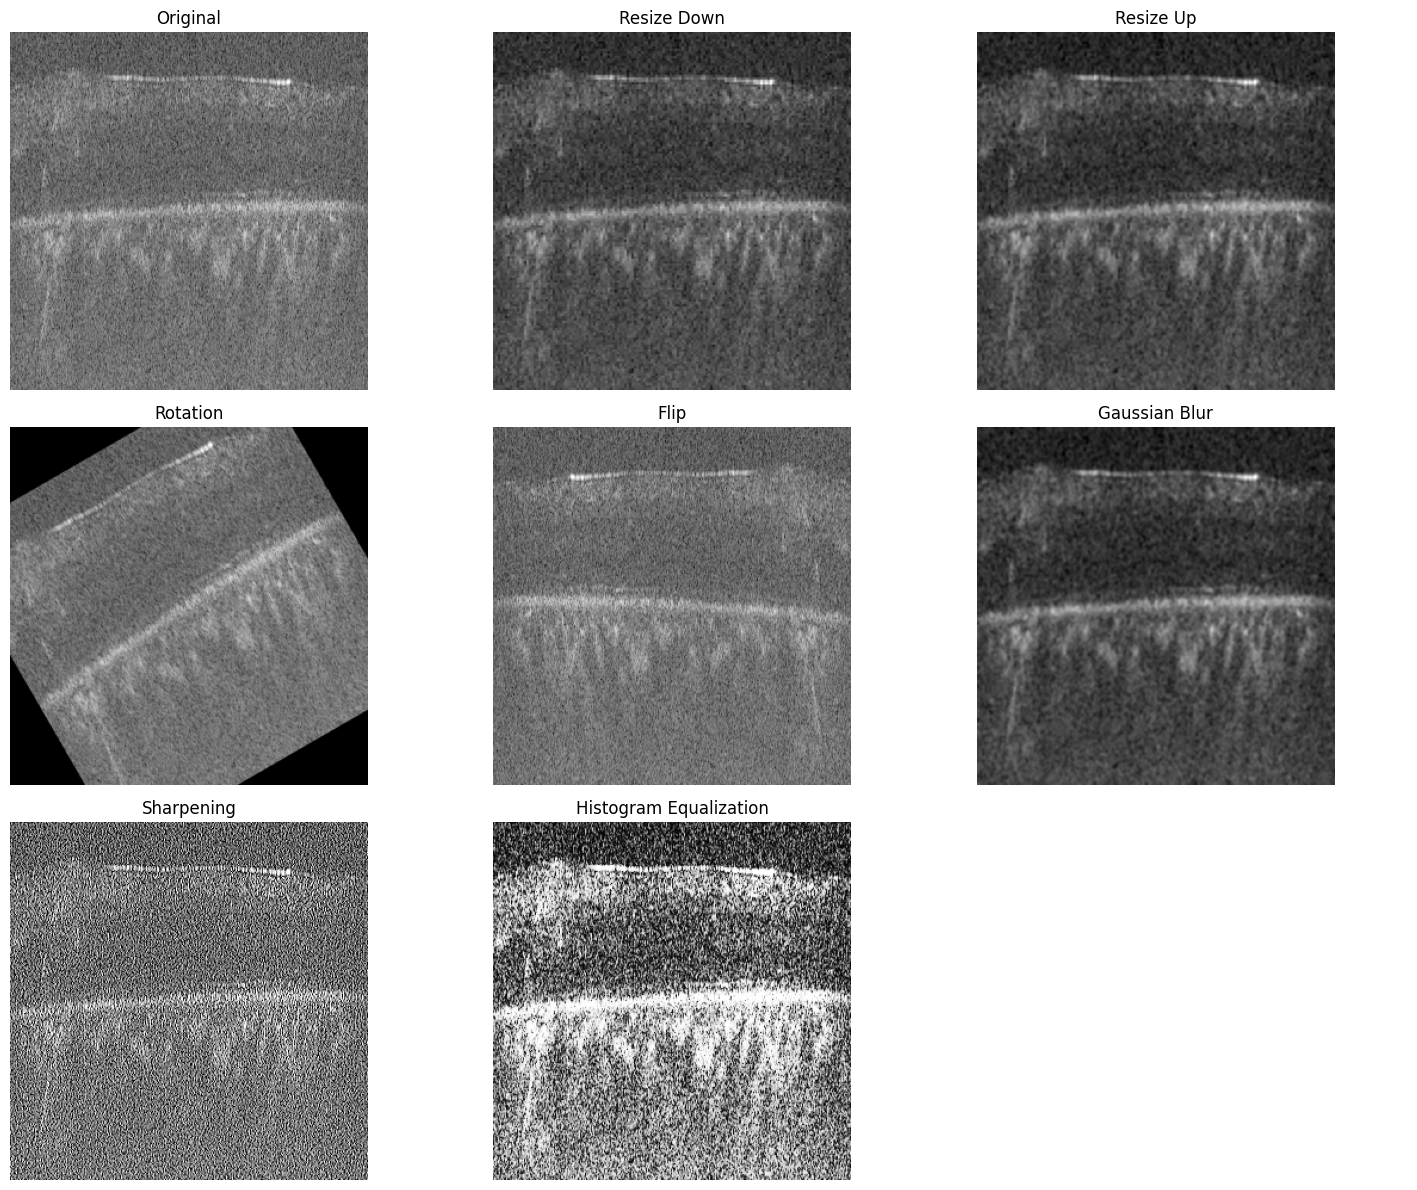

In [23]:
sample_path = choose_sample_image()

if sample_path is None:
    print("No sample image available yet.")
else:
    gray_image = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)

    if gray_image is None:
        print("OpenCV could not read the sample image as grayscale.")
    else:
        height, width = gray_image.shape

        resized_down = cv2.resize(gray_image, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
        resized_up = cv2.resize(resized_down, (width, height), interpolation=cv2.INTER_LINEAR)

        center = (width // 2, height // 2)
        rotation_matrix = cv2.getRotationMatrix2D(center, 30, 1.0)
        rotated = cv2.warpAffine(gray_image, rotation_matrix, (width, height))

        flipped = cv2.flip(gray_image, 1)
        gaussian_blur = cv2.GaussianBlur(gray_image, (5, 5), 0)

        sharpening_kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])
        sharpened = cv2.filter2D(gray_image, -1, sharpening_kernel)

        if gray_image.dtype == np.uint8:
            histogram_input = gray_image
        else:
            histogram_input = cv2.normalize(gray_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        histogram_equalized = cv2.equalizeHist(histogram_input)

        operations = [
            ("Original", gray_image),
            ("Resize Down", resized_down),
            ("Resize Up", resized_up),
            ("Rotation", rotated),
            ("Flip", flipped),
            ("Gaussian Blur", gaussian_blur),
            ("Sharpening", sharpened),
            ("Histogram Equalization", histogram_equalized)
        ]

        columns = 3
        rows = (len(operations) + columns - 1) // columns
        fig, axes = plt.subplots(rows, columns, figsize=(15, 4 * rows))
        axes = np.array(axes).reshape(-1)

        for axis, (title, image) in zip(axes, operations):
            axis.imshow(image, cmap="gray")
            axis.set_title(title)
            axis.axis("off")

        for axis in axes[len(operations):]:
            axis.axis("off")

        plt.tight_layout()
        plt.show()


Loading first 5 images from Data_jpg.
Filename: RawDataQA-1-1 (1).jpg
  Shape: (300, 300)
  Dtype: uint8
Filename: RawDataQA-1-1 (10).jpg
  Shape: (300, 300)
  Dtype: uint8
Filename: RawDataQA-1-1 (100).jpg
  Shape: (300, 300)
  Dtype: uint8
Filename: RawDataQA-1-1 (101).jpg
  Shape: (300, 300)
  Dtype: uint8
Filename: RawDataQA-1-1 (102).jpg
  Shape: (300, 300)
  Dtype: uint8


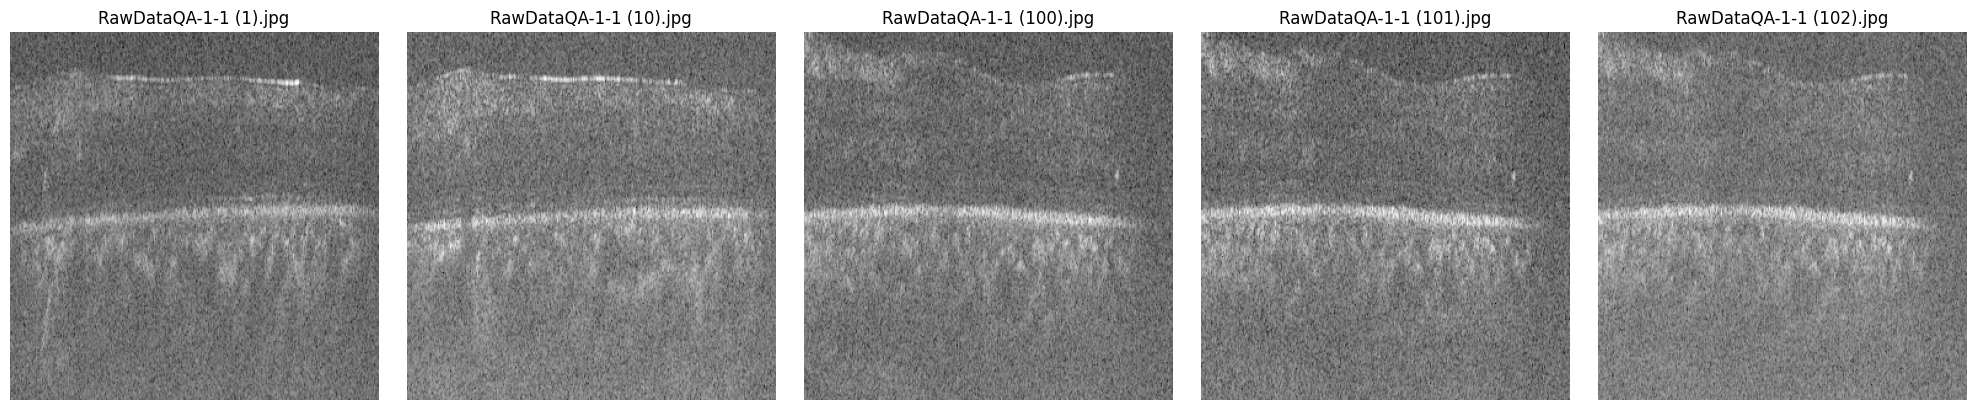

In [24]:
tiff_files, jpg_files, denoised_files = refresh_file_lists()

image_files = jpg_files
source_name = "Data_jpg"

if len(image_files) == 0:
    image_files = tiff_files
    source_name = DATA_DIR.name

if len(image_files) == 0:
    print("No images found for multiple image loading yet.")
else:
    first_images = image_files[:5]
    print(f"Loading first {len(first_images)} images from {source_name}.")

    fig, axes = plt.subplots(1, len(first_images), figsize=(4 * len(first_images), 4))

    if len(first_images) == 1:
        axes = [axes]

    for index, file in enumerate(first_images):
        image = cv2.imread(file, cv2.IMREAD_UNCHANGED)

        print("Filename:", Path(file).name)

        if image is None:
            print("  Could not read this image.")
            axes[index].axis("off")
            continue

        print("  Shape:", image.shape)
        print("  Dtype:", image.dtype)

        if len(image.shape) == 2:
            axes[index].imshow(image, cmap="gray")
        else:
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            axes[index].imshow(rgb_image)

        axes[index].set_title(Path(file).name)
        axes[index].axis("off")

    plt.tight_layout()
    plt.show()


In [25]:
tiff_files, jpg_files, denoised_files = refresh_file_lists()

data_folder_exists = DATA_DIR.exists()
tiff_count = len(tiff_files)
jpg_count = len(jpg_files)
denoised_count = len(denoised_files)

pipeline_success = (
    data_folder_exists
    and tiff_count > 0
    and jpg_count == tiff_count
    and denoised_count == tiff_count
)

print("Final Summary")
print("-------------")
print("Original data folder exists:", data_folder_exists)
print("Data folder used:", DATA_DIR)
print("Number of TIFF images:", tiff_count)
print("Number of JPG images:", jpg_count)
print("Number of denoised images:", denoised_count)

if pipeline_success:
    print("Pipeline status: SUCCESS")
else:
    if not data_folder_exists:
        print("Pipeline status: WAITING FOR DATA FOLDER")
    elif tiff_count == 0:
        print("Pipeline status: WAITING FOR TIFF IMAGES")
    else:
        print("Pipeline status: INCOMPLETE")
        print("Run the conversion and denoising sections again, then check the counts.")


Final Summary
-------------
Original data folder exists: True
Data folder used: /Users/khalidatef/Documents/image-processing-project/Data
Number of TIFF images: 18038
Number of JPG images: 18038
Number of denoised images: 18038
Pipeline status: SUCCESS
